# 공장 가동능력 대 처리량: PROC SGPLOT를 이용한 2차원 포트폴리오 분석

## 요약

개별생산(discrete manufacturing) 포트폴리오에서는 모든 제품라인에 대해 동시에 중요한 두 숫자가 있다: **얼마나 많은 설비 가동능력을 소모하는가**와 **실제로 얼마나 많은 양품을 산출하는가**이다. 1차원 막대그래프로는 둘 중 하나만 보여줄 수 있다. 이 노트북은 `PROC SGPLOT`으로 두 지표를 함께 시각화하며, 핵심 뷰로 **버블 플롯**을 사용한다 — 각 라인은 가동능력(x)과 처리량(y)으로 위치가 정해지고, 버블 크기는 생산성(설비시간당 생산량)을 나타낸다. 오른쪽 아래에 위치한 라인(가동능력은 많이 쓰지만 산출은 적음)은 가동능력을 잡아먹는 라인이고, 왼쪽 위에 큰 버블로 위치한 라인은 고수익 라인이다. 이어서 그룹 막대뷰가 공장별로 처리량을 분해하고, 생산성 순위표가 그 격차를 확인해 준다.

실제 실행 결과(3개 공장에 걸친 8개 제품라인, 24개 라인×공장 셀로 집계된 100개 교대별 가동기록)를 기준으로 분석해 보면, **주조(Casting)**가 포트폴리오에서 가장 뚜렷한 가동능력 낭비 라인임을 알 수 있다(설비시간당 양품 14.3개 — 전체 가동능력의 10.1%를 소모하지만 양품의 3.2%만 산출). 반면 **포장(Packaging)**은 단연 돋보이는 고수익 라인이다(시간당 119.2개 — 가동능력의 9.1%로 산출량의 23.8%를 만들어낸다). 공장 간에는 **슈투트가르트**가 시간당 49.9개로 가장 뜨겁고, **몬테레이**가 41.6개로 가장 낮다.

## 데이터 출처

| 출처 | 설명 | 레코드 수 |
|--------|-------------|--------|
| WORK.PRODUCTION_RUNS | 8개 제품라인 × 3개 공장 × 3개 교대에 걸친 합성 교대별 가동기록 — 예정 가동시간, 실가동시간, 다운타임, 총생산/불량/양품 수량 (무라이선스 모드에서 100개 관측치로 제한) | 100 |
| WORK.LINE_CAPACITY | 제품라인·공장별로 집계한 요약: 총 가동능력 시간(x), 생산된 양품 수량(y), 양품 수율(%) | 24 |

*모든 데이터는 고정 시드로 노트북 내에서 생성된 합성 데이터이며, 외부 파일이나 네트워크는 사용하지 않는다.*

# 공장 가동능력 대 처리량 분석

**분야:** 개별생산 제조업 — 운영/산업공학

**절차:** `PROC SGPLOT` (ODS 통계 그래픽)

일반적인 막대그래프는 범주당 하나의 반응변수만 보여준다. 생산 포트폴리오를 **두 개**의 수치 차원에서 동시에 비교하려면 — *각 제품라인이 얼마나 많은 가동능력을 소모하는지* 대 *실제로 얼마나 많은 산출을 내는지* — 둘을 같은 화면에 배치하는 플롯이 필요하다. `PROC SGPLOT`의 `BUBBLE` 문이 정확히 그 일을 한다. 각 라인을 가동능력(x)과 양품 수량(y)으로 위치시키고, 세 번째 지표인 생산성이 버블 크기를 결정하게 한다. 오른쪽 멀리 있지만 낮게 위치한 라인은 가동능력 낭비 라인이고, 왼쪽 위에 큰 버블로 있는 라인은 지켜야 할 고수익 라인이다. 이 노트북은 현실적인 합성 생산 데이터셋을 구성하고, 버블 플롯·공장별 그룹 막대그래프·단일 공장 드릴다운·공장 간 나란히 비교하는 클러스터 막대그래프로 SGPLOT을 이끌어 간다.

> **PROC GAREABAR에 대한 참고.** *막대* 하나에 두 차원을 인코딩하는 고전적인 SAS/GRAPH 방식은 `PROC GAREABAR`(막대 너비가 한 변수를, 높이가 다른 변수를 나타내는 ActiveX 전용 영역막대그래프)이다. GAREABAR는 **이 Jenner 빌드에서 아직 구현되어 있지 않으며**, 그 공백은 보관된 테스트 `tests/400996_nb_gareabar_unimplemented`로 추적되고 있다. 이 노트북은 완전히 지원되는 `PROC SGPLOT`으로 동일한 분석 목표에 도달하며, 그 버블 뷰와 그룹 막대 뷰는 동일한 가동능력 대 처리량 이야기를 전달한다.

## 1. 합성 생산 데이터 생성

3개 공장으로 이루어진 개별생산 네트워크에 대해 6주치 교대별 가동기록을 시뮬레이션한다. 각 제품라인은 기준 사이클타임과 불량률을 가지며, 처리량은 예정 가동시간, 라인별 효율, 무작위 다운타임에 의해 결정된다. `call streaminit`으로 시드를 고정하여 노트북이 완전히 재현 가능하도록 한다 — 외부 파일도, 네트워크도 없다.

In [1]:
/* --------------------------------------------------------
   합성 교대별 생산 가동기록
   제품라인 8개 x 공장 3개 x 교대 3개 x 약 10일
   너비 변수 = 예정 가동시간 (가동능력)
   반응 변수 = 생산된 양품 수량 (처리량)
   -------------------------------------------------------- */
데이터 work.production_runs;
    호출 streaminit(20260531);
    길이 product_line $20 plant $24 shift $12;

    /* 제품라인별 설비시간당 생산량(공칭값) */
    배열 line_rate[8] _temporary_
        (42 28 35 18 60 75 90 140);
    /* 제품라인별 기준 불량률 */
    배열 line_scrap[8] _temporary_
        (0.04 0.06 0.05 0.09 0.03 0.02 0.02 0.01);
    /* 공장별 효율 배수 */
    배열 plant_eff[3] _temporary_ (1.00 0.92 1.08);
    배열 shift_eff[3] _temporary_ (1.00 0.95 0.88);

    반복 day = 1 까지 10;
        반복 li = 1 까지 8;
            만약 li=1 이면 product_line="스탬핑";
            아니면 만약 li=2 이면 product_line="용접";
            아니면 만약 li=3 이면 product_line="가공";
            아니면 만약 li=4 이면 product_line="주조";
            아니면 만약 li=5 이면 product_line="사출";
            아니면 만약 li=6 이면 product_line="조립";
            아니면 만약 li=7 이면 product_line="마감";
            아니면 product_line="포장";

            반복 pi = 1 까지 3;
                만약 pi=1 이면 plant="디트로이트";
                아니면 만약 pi=2 이면 plant="몬테레이";
                아니면 plant="슈투트가르트";

                반복 si = 1 까지 3;
                    만약 si=1 이면 shift="주간조";
                    아니면 만약 si=2 이면 shift="오후조";
                    아니면 shift="야간조";

                    /* 해당 교대의 예정 가동시간 */
                    sched_hours = round(6.5 + rand('uniform') * 1.5, 0.1);

                    /* 계획되지 않은 다운타임이 가동능력을 잠식 */
                    downtime_hours =
                        round(rand('uniform') * 1.2
                              * (2 - plant_eff[pi]), 0.1);
                    run_hours = MAX(sched_hours - downtime_hours, 0.5);

                    /* 잡음이 섞인 실효 처리율 */
                    eff = plant_eff[pi] * shift_eff[si]
                          * (0.9 + rand('uniform') * 0.2);
                    gross_units =
                        round(run_hours * line_rate[li] * eff);

                    scrap_rate = line_scrap[li]
                                 * (0.7 + rand('uniform') * 0.6);
                    scrap_units = round(gross_units * scrap_rate);
                    good_units  = gross_units - scrap_units;

                    run_date = '05JAN2026'd + (day - 1);
                    출력;
                종료;
            종료;
        종료;
    종료;
    유지 run_date product_line plant shift
         sched_hours run_hours downtime_hours
         gross_units scrap_units good_units;
    형식 run_date date9.;
실행;

처리 인쇄 데이터=work.production_runs(obs=8) noobs;
    라벨 run_date="생산일자" product_line="제품라인" plant="공장" shift="교대"
          sched_hours="예정 가동시간" run_hours="실가동시간" downtime_hours="다운타임(시간)"
          gross_units="총생산량" scrap_units="불량 수량" good_units="양품 수량";
    제목 "합성 교대별 생산 가동기록 표본";
실행;
제목;

                                                   합성 교대별 생산 가동기록 표본                                                    

        생산일자          제품라인                  공장         교대              예정 가동시간            실가동시간              다운타임(시간)          총생산량          불량 수량          양품 수량
   05JAN2026  스탬핑           디트로이트               주간조                        7.8              6.7                   1.1           306             14            292
   05JAN2026  스탬핑           디트로이트               오후조                        6.8              6.5                   0.3           259             12            247
   05JAN2026  스탬핑           디트로이트               야간조                          8              7.6                   0.4           269             11            258
   05JAN2026  스탬핑           몬테레이                주간조                        7.9              6.8                   1.1           283             12            271
   05JAN2026  스탬핑           몬테레이                오후조                 


NOTE: DATA work.production_runs

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.production_runs (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.17 seconds
  cpu   0.17 seconds
NOTE: PROC PRINT data=work.production_runs

NOTE: PROC PRINT completed: 8 observations printed, 10 variables


## 2. 라인·공장 수준으로 집계

플롯은 범주당 점 하나씩을 비교하므로, 교대 단위 상세 데이터를 제품라인·공장별 요약으로 끌어올린다. `total_capacity`(예정 가동시간의 합)가 **x** 차원이 되고, `good_units`(합격 산출량의 합)가 **y** 차원이 되며, `units_per_hr`(양품 수량 ÷ 가동능력 시간)이 버블 크기를 정하는 생산성 지표가 된다. 이후 그룹화 변수로 쓸 수 있도록 `plant`는 그대로 유지한다. 포트폴리오 버블 플롯을 위해 공장을 가로지르는 라인 수준 집계도 만든다.

In [2]:
/* --------------------------------------------------------
   product_line x plant로 집계
   total_capacity -> x (가동능력 시간)
   good_units     -> y (처리량)
   units_per_hr   -> 버블 크기 (생산성)
   -------------------------------------------------------- */
처리 평균 데이터=work.production_runs NOPRINT NWAY;
    분류 product_line plant;
    변수 sched_hours good_units scrap_units;
    출력 out=work.line_capacity(제거=_type_ _freq_)
        sum(sched_hours)  = total_capacity
        sum(good_units)   = good_units
        sum(scrap_units)  = scrap_units;
실행;

데이터 work.line_capacity;
    설정 work.line_capacity;
    units_per_hr = good_units / total_capacity;
    yield_pct    = 100 * good_units / (good_units + scrap_units);
    형식 units_per_hr 6.1 yield_pct 5.1;
실행;

처리 정렬 데이터=work.line_capacity;
    기준 product_line plant;
실행;

/* 전체 3개 공장을 가로지르는 라인 수준 집계 (포트폴리오 뷰용) */
처리 평균 데이터=work.line_capacity NOPRINT NWAY;
    분류 product_line;
    변수 total_capacity good_units;
    출력 out=work.line_total(제거=_type_ _freq_)
        sum(total_capacity) = total_capacity
        sum(good_units)     = good_units;
실행;

데이터 work.line_total;
    설정 work.line_total;
    units_per_hr = good_units / total_capacity;
    형식 units_per_hr 6.1;
실행;

처리 정렬 데이터=work.line_total;
    기준 units_per_hr;
실행;

처리 인쇄 데이터=work.line_total noobs;
    변수 product_line total_capacity good_units units_per_hr;
    라벨 product_line="제품라인" total_capacity="총 가동능력 시간" good_units="양품 수량" units_per_hr="시간당 생산성";
    제목 "생산성 기준 포트폴리오 라인 순위 (설비시간당 양품 수량)";
실행;
제목;

                                            생산성 기준 포트폴리오 라인 순위 (설비시간당 양품 수량)                                            

        제품라인                총 가동능력 시간          양품 수량              시간당 생산성
주조                               73.4           1050                 14.3
용접                              130.8           3038                 23.2
가공                              128.9           3762                 29.2
스탬핑                             130.7           4713                 36.1
사출                               66.2           3430                 51.8
조립                               67.3           4289                 63.7
마감                               64.6           4927                 76.3
포장                               65.9           7855                119.2




NOTE: PROC MEANS
NOTE: Output dataset work.line_capacity has 24 observations and 5 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_capacity


NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_capacity

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 24 rows from work.line_capacity.
NOTE: Wrote work.line_capacity (24 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC MEANS
NOTE: Output dataset work.line_total has 8 observations and 3 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.line_total


NOTE: Read 8 rows from work.line_total.
NOTE: Wrote work.line_total (8 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=work.line_total

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 8 rows from work.line_total.
NOTE: Wrote 

## 3. ODS 그래픽 대상 열기

`PROC SGPLOT`은 ODS 통계 그래픽을 통해 렌더링된다. 각 플롯이 이미지로 출력되도록 `ODS HTML` 대상을 열고 `ODS GRAPHICS ON`을 지정한다. ActiveX 전용 SAS/GRAPH 프로시저와 달리 SGPLOT은 장치 독립적이므로 특별한 디바이스 드라이버가 필요하지 않다.

In [3]:
ODS html;
ODS GRAPHICS ON;


NOTE: ODS HTML: Destination opened.
NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).


## 4. 포트폴리오 버블 플롯 — 가동능력 대 처리량

핵심 뷰: `BUBBLE x=total_capacity y=good_units size=units_per_hr`. 각 제품라인은 버블 하나로 표시되며, 총 가동능력 시간(x)과 총 양품 수량(y)으로 위치가 정해지고 버블 면적은 생산성 지표에 비례한다. `DATALABEL=`은 각 버블 옆에 라인 이름을 출력한다. 이것이 공장 관리자가 원하는 2차원 비교이다 — 가동능력 낭비 라인은 **오른쪽 아래**(시간은 많고 산출은 적으며 버블이 작음)로 떨어지고, 고수익 라인은 **왼쪽 위**(시간은 적고 산출은 많으며 버블이 큼)로 올라간다.

                                                 생산 포트폴리오 - 가동능력 대 처리량                                                  
                                        x = 예정 가동시간; y = 양품 수량; 버블 크기 = 시간당 생산성                                         


오른쪽 아래 = 가동능력 낭비 라인; 큰 버블과 함께 왼쪽 위 = 고수익 라인.



NOTE: Option TITLE changed to 생산 포트폴리오 - 가동능력 대 처리량.
NOTE: Option TITLE2 changed to x = 예정 가동시간; y = 양품 수량; 버블 크기 = 시간당 생산성.
NOTE: Option FOOTNOTE changed to 오른쪽 아래 = 가동능력 낭비 라인; 큰 버블과 함께 왼쪽 위 = 고수익 라인..
NOTE: PROC SGPLOT data=work.line_total

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


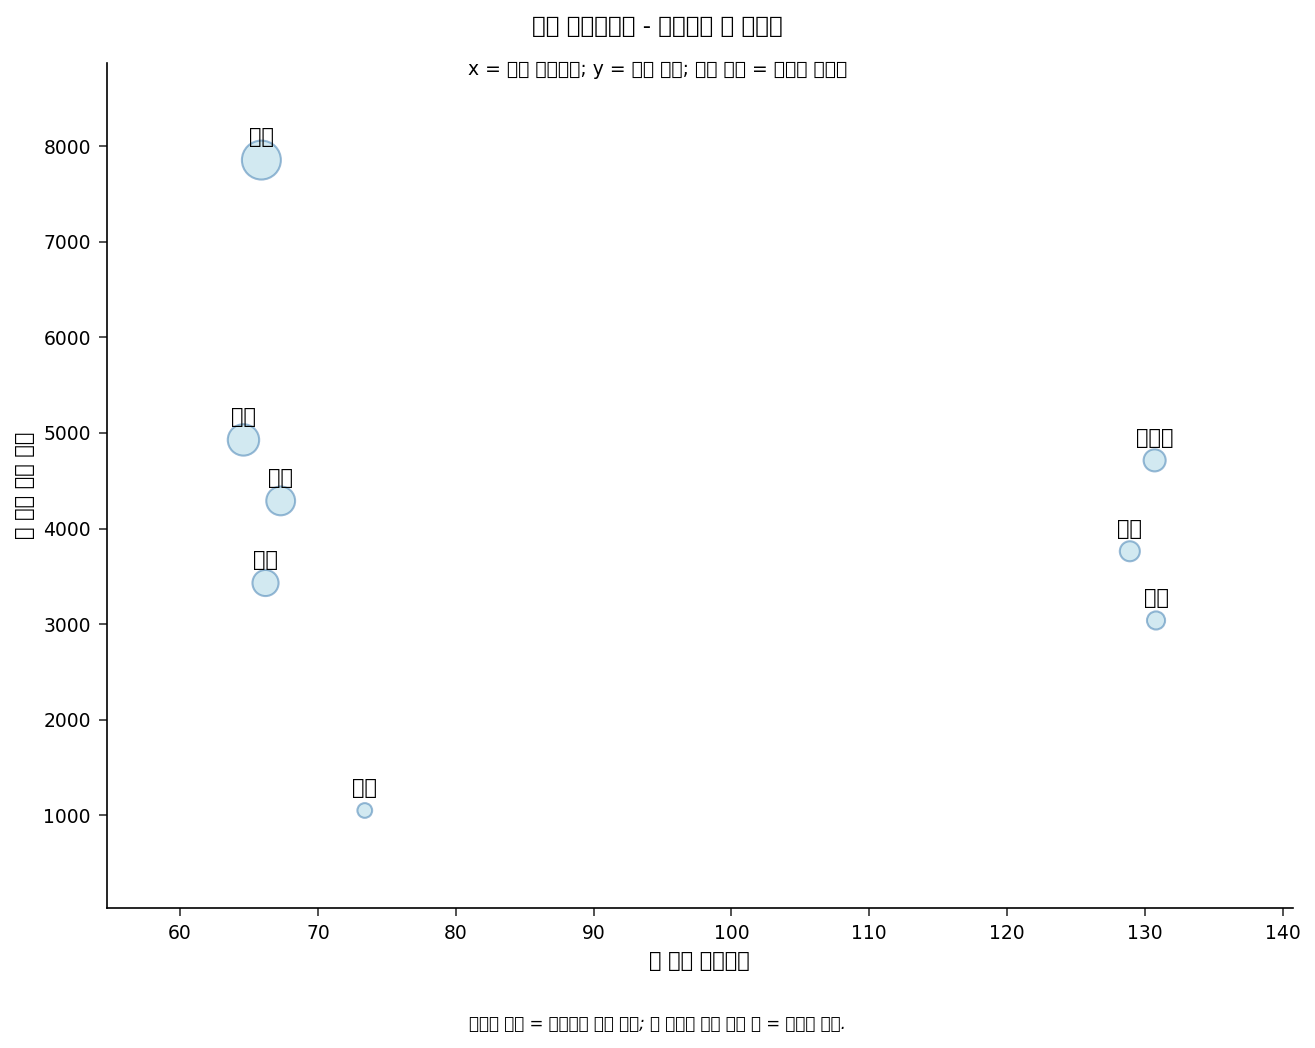

In [4]:
제목 "생산 포트폴리오 - 가동능력 대 처리량";
title2 "x = 예정 가동시간; y = 양품 수량; 버블 크기 = 시간당 생산성";
footnote JUSTIFY=LEFT
    "오른쪽 아래 = 가동능력 낭비 라인; 큰 버블과 함께 왼쪽 위 = 고수익 라인.";

처리 SGPLOT 데이터=work.line_total;
    bubble x=total_capacity y=good_units size=units_per_hr /
        DATALABEL=product_line
        fillattrs=(color=cx2C5F8A)
        TRANSPARENCY=0.45;
    XAXIS 라벨="총 예정 가동시간";
    YAXIS 라벨="총 생산 양품 수량";
    라벨 product_line="제품라인" total_capacity="총 가동능력 시간" good_units="양품 수량" units_per_hr="시간당 생산성";
실행;

제목; title2; footnote;

## 5. 라인별 처리량을 공장별로 분해

각 라인의 산출이 세 공장에 어떻게 나뉘는지 보기 위해, `VBAR product_line / response=good_units group=plant` 차트가 각 막대 안에서 공장별 기여도를 쌓아 보여준다. 이는 분해 뷰로, 막대의 전체 높이(라인별 양품 수량)와 막대 내부의 공장 구성을 동시에 보여주므로 한 공장이 산출을 독점하는 라인을 짚어낼 수 있다.

                                                  제품라인별 양품 수량, 공장별 누적                                                   
                                             막대 높이 = 총 양품 수량; 구간 = 공장별 기여도                                              




NOTE: Option TITLE changed to 제품라인별 양품 수량, 공장별 누적.
NOTE: Option TITLE2 changed to 막대 높이 = 총 양품 수량; 구간 = 공장별 기여도.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot1.svg


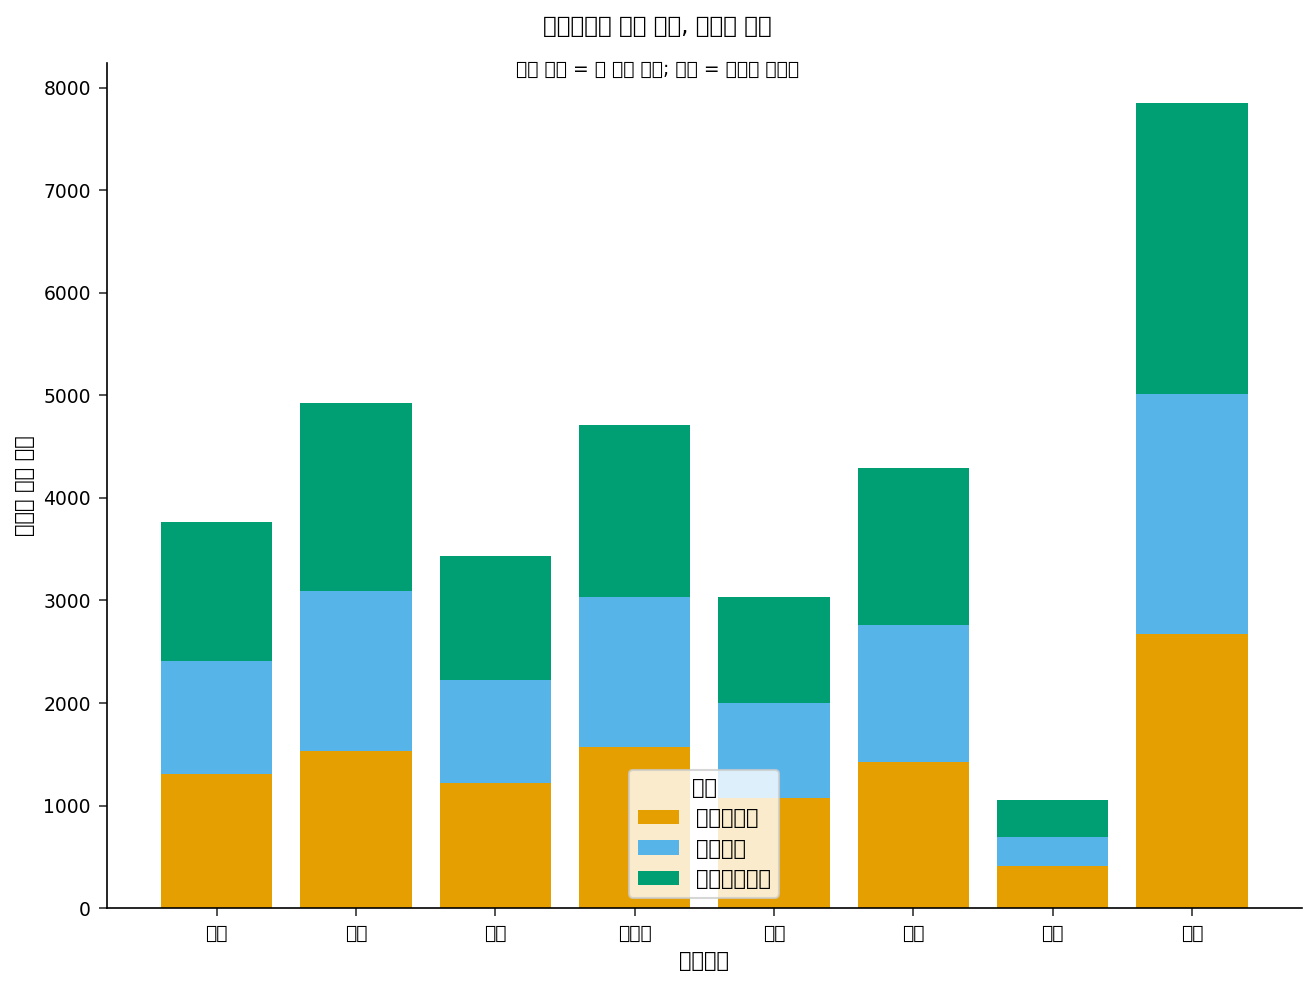

In [5]:
제목 "제품라인별 양품 수량, 공장별 누적";
title2 "막대 높이 = 총 양품 수량; 구간 = 공장별 기여도";

처리 SGPLOT 데이터=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=stack;
    XAXIS 라벨="제품라인" fitpolicy=ROTATE;
    YAXIS 라벨="생산된 양품 수량";
    keylegend / 제목="공장" position=bottom;
    라벨 product_line="제품라인" good_units="양품 수량" plant="공장";
실행;

제목; title2;

## 6. 단일 공장 생산성 드릴다운 (WHERE)

수평 막대(`HBAR`)는 긴 제품라인 레이블에 적합하다. `WHERE` 절로 슈투트가르트 공장만 추려내고, `units_per_hr`에 대해 막대를 그려 슈투트가르트의 라인을 생산성 순으로 순위 매긴다. 입력이 생산성 오름차순으로 정렬되어 있으므로 생산성이 가장 낮은 라인이 맨 아래에, 가장 높은 라인이 맨 위에 위치한다.

                                                슈투트가르트 공장 - 생산성 기준 라인 순위                                                


막대 길이 = 설비시간당 양품 수량 (단일 공장 드릴다운).



NOTE: Option TITLE changed to 슈투트가르트 공장 - 생산성 기준 라인 순위.
NOTE: Option FOOTNOTE changed to 막대 길이 = 설비시간당 양품 수량 (단일 공장 드릴다운)..
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot2.svg


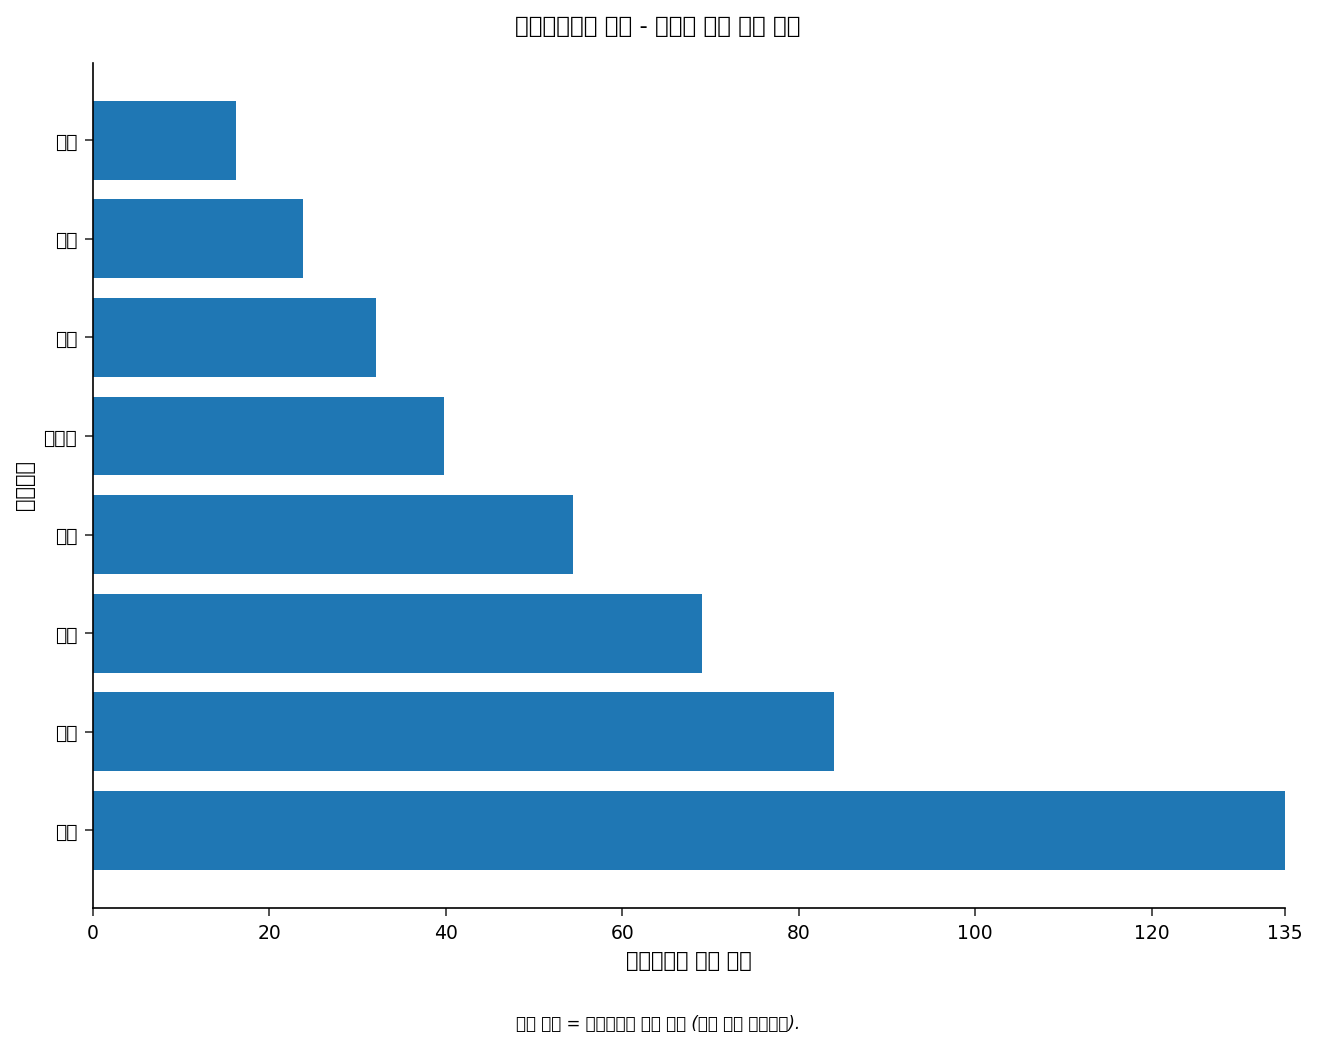

In [6]:
제목 "슈투트가르트 공장 - 생산성 기준 라인 순위";
footnote JUSTIFY=LEFT "막대 길이 = 설비시간당 양품 수량 (단일 공장 드릴다운).";

처리 SGPLOT 데이터=work.line_capacity;
    조건 plant = "슈투트가르트";
    HBAR product_line / RESPONSE=units_per_hr
        CATEGORYORDER=respasc
        fillattrs=(color=cx28A745);
    XAXIS 라벨="설비시간당 양품 수량";
    YAXIS 라벨="제품라인";
    라벨 product_line="제품라인" units_per_hr="시간당 생산성";
실행;

제목; footnote;

## 7. 공장 간 나란히 비교 (클러스터 막대)

세 공장을 라인별로 비교하기 위해, 클러스터 막대그래프(`GROUPDISPLAY=CLUSTER`)가 각 제품라인 안에서 디트로이트, 몬테레이, 슈투트가르트를 인접한 막대로 그린다. 이는 동등 비교가 가능한 공장 뷰로, 어떤 라인에서든 어느 공장이 가장 많은 양품을 산출했는지 바로 읽을 수 있어 공장 간 효율 차이(슈투트가르트가 가장 높고 몬테레이가 가장 낮음)가 직접 드러난다.

                                                 라인·공장별 양품 수량 - 나란히 비교                                                  
                                               클러스터 막대: 제품라인마다 공장별 막대 하나씩                                               




NOTE: Option TITLE changed to 라인·공장별 양품 수량 - 나란히 비교.
NOTE: Option TITLE2 changed to 클러스터 막대: 제품라인마다 공장별 막대 하나씩.
NOTE: PROC SGPLOT data=work.line_capacity

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot3.svg
NOTE: ODS Graphics is OFF.


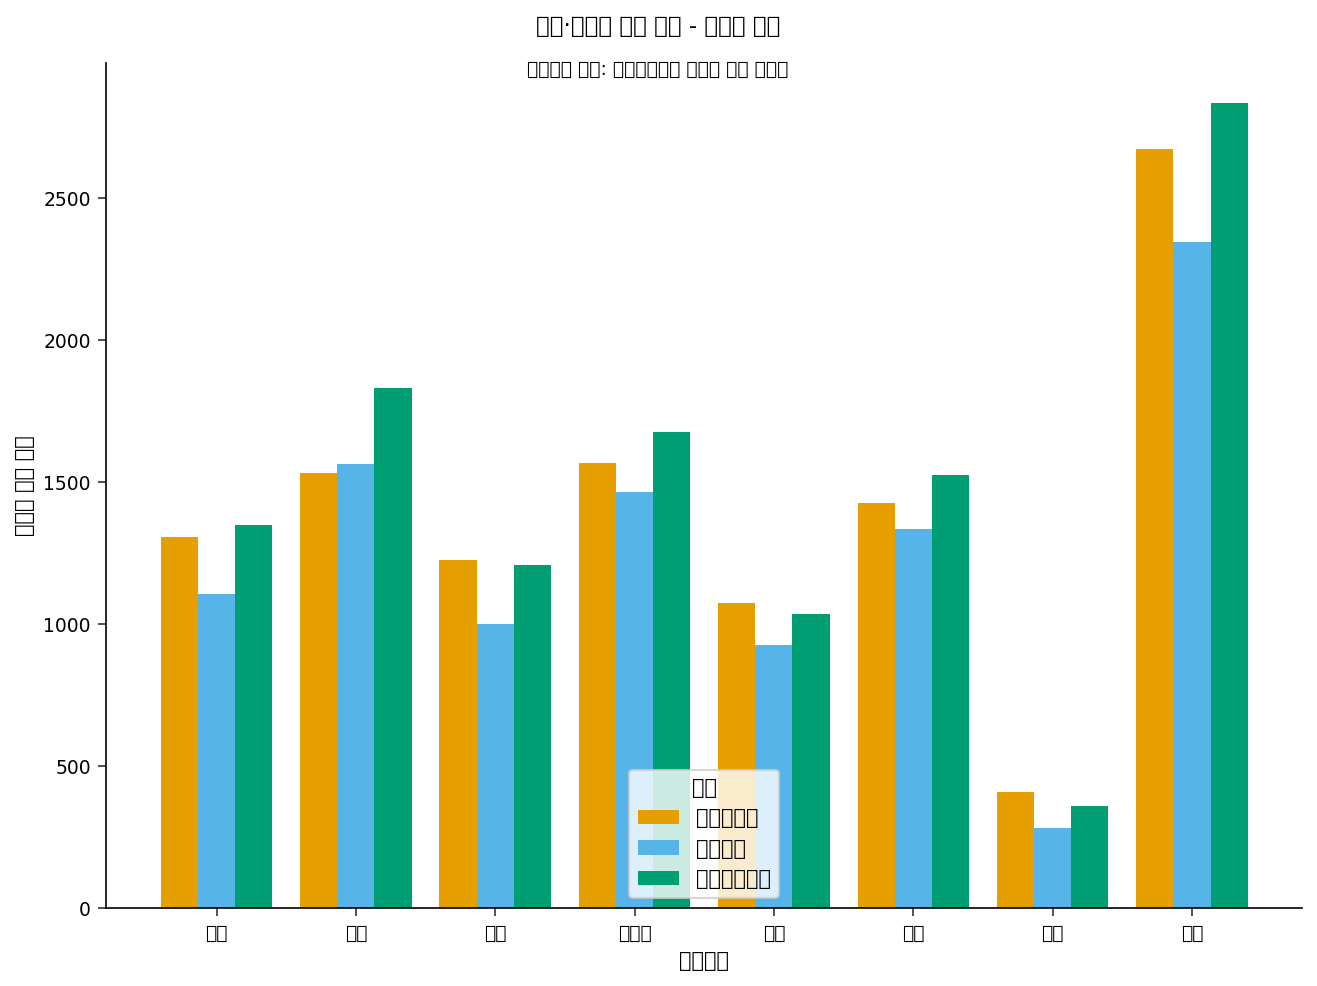

In [7]:
제목 "라인·공장별 양품 수량 - 나란히 비교";
title2 "클러스터 막대: 제품라인마다 공장별 막대 하나씩";

처리 SGPLOT 데이터=work.line_capacity;
    VBAR product_line / RESPONSE=good_units
        GROUP=plant
        GROUPDISPLAY=CLUSTER;
    XAXIS 라벨="제품라인" fitpolicy=ROTATE;
    YAXIS 라벨="생산된 양품 수량";
    keylegend / 제목="공장" position=bottom;
    라벨 product_line="제품라인" good_units="양품 수량" plant="공장";
실행;

제목; title2;

ODS GRAPHICS OFF;
ODS html CLOSE;

## 해석

가동능력과 처리량을 같은 축에 그리면 1차원 막대그래프라면 가려졌을 관계가 드러난다. **주조(Casting)**는 포트폴리오에서 가장 뚜렷한 가동능력 낭비 라인이다. 생산성 순위표에서 맨 아래인 **설비시간당 양품 14.3개**에 위치하며, 버블 플롯에서는 작은 버블로 왼쪽 아래에 떨어진다 — 총 예정 시간의 **10.1%**를 소모하지만 양품의 **3.2%**만 돌려준다(높은 불량률로 인해 수율도 약 91%로 가장 낮다). 사이클타임 단축과 불량 감소 개선(kaizen) 활동의 최우선 후보다. 반대쪽 끝에서는 **포장(Packaging)**이 **설비시간당 119.2개**로 단연 돋보이는 고수익 라인이다 — 처리량 축에서 높이 위치한 큰 버블로, 가동능력의 **9.1%**를 전체 양품의 **23.8%**로 바꾸어 낸다. 가동률을 지키는 것이 불균형하게 큰 산출로 이어진다. **마감(Finishing)**(시간당 76.3개)과 **조립(Assembly)**(63.7개)도 같은 고수익 패턴을 따른다.

이 패턴은 체계적이다. 느리고 가동능력을 많이 소모하는 네 개의 상류 라인 — 주조, 용접(시간당 23.2개), 가공(29.2개), 스탬핑(36.1개) — 은 함께 예정 시간의 약 **64%**를 소비하지만 양품의 약 **38%**만 산출하는 반면, 네 개의 빠른 하류 라인은 소모하는 시간 대비 과하게 산출한다. 공장별 누적 뷰와 나란히 비교한 클러스터 막대는 그 배후의 공장 차원을 보여준다 — **슈투트가르트**는 시간당 **49.9개**로 가장 뜨겁게 돌아가고, **디트로이트**는 중간인 **44.9개**, **몬테레이**는 **41.6개**로 뒤처진다 — 몬테레이의 모델링된 다운타임이 더 높다는 사실과 일치한다. 운영 관점에서는 예정 시간을 고수익 하류 라인 쪽으로 재배분하고, 몬테레이의 다운타임을 슈투트가르트의 관행에 견주어 벤치마킹할 것을 시사한다.

*합성 데이터일 뿐이다 — 이 수치는 실제 공장 성과가 아니라 PROC SGPLOT을 이용한 2차원 가동능력-대-처리량 시각화의 예시일 뿐이다.*